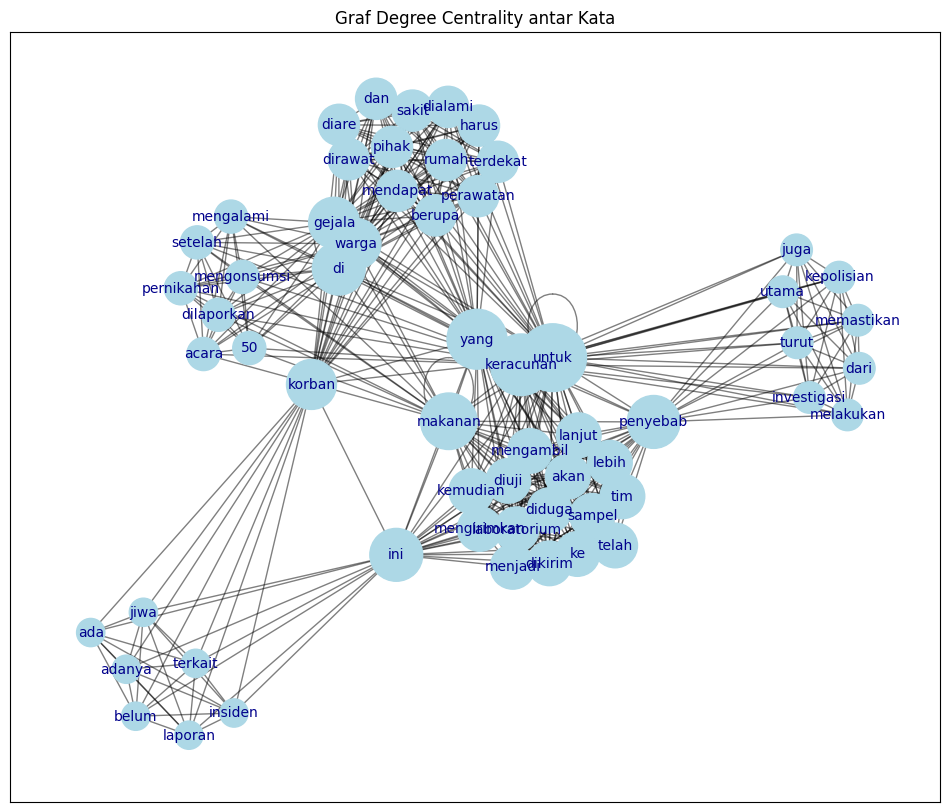

Kata-kata Penting Berdasarkan Degree Centrality:
 ['untuk', 'keracunan', 'yang', 'makanan', 'di', 'penyebab', 'ini']


In [9]:
import streamlit as st
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
import networkx as nx
import matplotlib.pyplot as plt

# Download stopwords untuk bahasa Indonesia
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

# Fungsi preprocessing yang disesuaikan
def remove_url(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def remove_html(text):
    return re.sub(r'<.*?>', '', text)

def remove_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_symbols(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

def case_folding(text):
    return text.lower()

def tokenize(text):
    return text.split()

def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# Input berita
st.title("Proses Berita dan Analisis Similarity")
user_input = st.text_area("Masukkan Berita Baru", "")

if user_input:
    # 2. Pisah kalimat berdasarkan titik
    sentences = [s.strip() for s in user_input.split('.') if s.strip()]
    result_list = [{'kalimat ke n': f"Kalimat ke {i+1}", 'kalimat': sentence} for i, sentence in enumerate(sentences)]
    result_df = pd.DataFrame(result_list)

    # 3. Preprocessing
    result_df['clean'] = result_df['kalimat'].apply(remove_url).apply(remove_html).apply(remove_emoji).apply(remove_symbols).apply(remove_numbers).apply(case_folding)
    result_df['tokenize'] = result_df['clean'].apply(tokenize)
    result_df['stopword removal'] = result_df['tokenize'].apply(remove_stopwords)
    result_df['stemming'] = result_df['stopword removal'].apply(stemming)
    result_df['final'] = result_df['stemming']

    # 4. TF-IDF
    documents = result_df['final'].tolist()
    tfidf_vectorizer = TfidfVectorizer()
    tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
    feature_names = tfidf_vectorizer.get_feature_names_out()
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
    tfidf_df.insert(0, 'kalimat ke n', result_df['kalimat ke n'])

    st.subheader("TF-IDF Matrix")
    st.write(tfidf_df)

    # 5. Cosine Similarity
    cosine_sim = cosine_similarity(tfidf_matrix)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=result_df['kalimat ke n'], columns=result_df['kalimat ke n'])

    # 6. Threshold 0.01 dan Adjacency Matrix
    threshold = 0.01
    adjacency_matrix = np.where(cosine_sim >= threshold, 1, 0)
    adjacency_df = pd.DataFrame(adjacency_matrix, index=result_df['kalimat ke n'], columns=result_df['kalimat ke n'])

    st.subheader("Cosine Similarity Matrix")
    st.write(cosine_sim_df)

    st.subheader("Adjacency Matrix")
    st.write(adjacency_df)

    # 8. Graph Adjacency
    G = nx.from_numpy_array(adjacency_matrix)
    mapping = {i: f"Kalimat ke {i+1}" for i in range(len(result_df))}
    G = nx.relabel_nodes(G, mapping)

    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, font_color='black')
    st.pyplot(plt)

    # 9. Centrality Measures
    betweenness_centrality = nx.betweenness_centrality(G)
    degree_centrality = nx.degree_centrality(G)
    closeness_centrality = nx.closeness_centrality(G)

    centrality_df = pd.DataFrame({
        'Kalimat': list(betweenness_centrality.keys()),
        'Betweenness Centrality': list(betweenness_centrality.values()),
        'Degree Centrality': list(degree_centrality.values()),
        'Closeness Centrality': list(closeness_centrality.values())
    }).sort_values(by=['Degree Centrality'], ascending=False)

    st.subheader("Centrality Measures")
    st.write(centrality_df)

    # 10. Top N Selection
    top_n = st.selectbox("Pilih top N berdasarkan Degree Centrality", [3, 5, 10])
    top_n_df = centrality_df.nlargest(top_n, 'Degree Centrality')

    # 11. Merge untuk hasil final
    top_n_final_df = pd.merge(top_n_df[['Kalimat']], result_df, left_on='Kalimat', right_on='kalimat ke n')
    st.subheader(f"Top {top_n} Kalimat berdasarkan Degree Centrality")
    st.write(top_n_final_df[['kalimat ke n', 'final']])